<a href="dependencies/banner.jpeg">
      <img src="dependencies/banner.jpeg" alt="image0" width="100%">
</a>

# Resonator Spectroscopy
In a resonator spectroscopy experiment, we sweep the frequency of a microwave tone
applied to the readout line. When the drive tone frequency matches the resonator's
resonance frequency, a change in the amplitude and/or phase of the reflected
signal is observed.

In [1]:
from dependencies.analysis_utils import ResonatorSpectroscopyAnalysis
from xarray import open_dataset

from qblox_scheduler import HardwareAgent, Schedule
from qblox_scheduler.operations import IdlePulse, Measure
from qblox_scheduler.operations.expressions import DType
from qblox_scheduler.operations.loop_domains import arange, linspace

from qblox_sim.simulator import QbloxQutipSimulator

Generating hash table for SingleQubitClifford.
Hash table generated.
Generating hash table for TwoQubitCliffordCZ.
Hash table generated.
Generating hash table for TwoQubitCliffordZX.
Hash table generated.


/opt/anaconda3/envs/blox_311/lib/python3.11/site-packages/quantify_core/visualization/instrument_monitor.py:13: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import strip_attrs


## Setup
The hardware agent manages the connection to the instrument and ensures that pulses and acquisitions happen over the appropriate input and output channels of the Cluster.
The cell below creates an instance of the `HardwareAgent` based on the hardware- and device-under-test configuration files in the `./dependencies/configs` folder, allowing us to start doing measurements.
We also define some convenient aliases to use throughout our measurements.
For a more thorough discussion of the hardware- and device-under-test configuration files, check out [this tutorial](000_transmon_setup.ipynb).

In [2]:
# Set up hardware agent, this automatically connects to the instrument
hw_agent = HardwareAgent(
    hardware_configuration="./dependencies/configs/hw_config.json",
    quantum_device_configuration="./dependencies/configs/dut_config.json",
)

# convenience aliases
q0 = hw_agent.quantum_device.get_element("q0")  # Qubits 0 and 2 are measured using QRM-RF + QCM-RF
q2 = hw_agent.quantum_device.get_element("q2")
q3 = hw_agent.quantum_device.get_element("q3")  # Qubit 3 is measured using QRC

cluster = hw_agent.get_clusters()["cluster"]
hw_options = hw_agent.hardware_configuration.hardware_options
qubit = q0

# -----------------------------------------------------------------------------
# SIMULATOR SETUP
# -----------------------------------------------------------------------------
sim_params = {
    'f_q': 5.0e9,
    'f_d': 5.0e9,
    'f_res': qubit.clock_freqs.readout,
    'f_d_res': qubit.clock_freqs.readout,
    'chi': 1.0e6,
    'cable_delay': 120e-9,
    'N_q': 3,
    'alpha': -300.0e6,
    'rabi_freq_per_volt': 10.0e6,
    'rabi_freq_res_per_volt': 10.0e6,
    'T1': 20e-6,
    'T2': 15e-6,
    'kappa': 1e6,
    'N_res': 5,
}

simulator = QbloxLoopSimulator(sim_params)

/opt/anaconda3/envs/blox_311/lib/python3.11/site-packages/qblox_scheduler/qblox/hardware_agent.py:485: UserWarning: cluster: Trying to instantiate cluster with ip 'None'.Creating a dummy cluster.
  warnings.warn(


## Experiment settings

In [3]:
# Frequency settings
frequency_center = qubit.clock_freqs.readout  # Hz
frequency_width = 5e6  # Hz
frequency_npoints = 300

repetitions = 1000

## Experiment schedule

In [4]:
spec_sched = Schedule("resonator_spectroscopy")
with (
    spec_sched.loop(arange(0, repetitions, 1, DType.NUMBER)),
    spec_sched.loop(
        linspace(
            start=frequency_center - frequency_width / 2,
            stop=frequency_center + frequency_width / 2,
            num=frequency_npoints,
            dtype=DType.FREQUENCY,
        )
    ) as freq,
):
    spec_sched.add(Measure(qubit.name, freq=freq, coords={"frequency": freq}, acq_channel="S_21"))
    spec_sched.add(IdlePulse(10e-6))  # Let the resonator decay

# Execute the experiment
sim_output = simulator.simulate(spec_sched)

if cluster.is_dummy:
    example_data = open_dataset(
        "./dependencies/datasets/resonator_spectroscopy.hdf5", engine="h5netcdf"
    )
    rs_data = example_data
else:
    rs_data = sim_output

KeyboardInterrupt: 

## Analyze the experiment

findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


...

findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


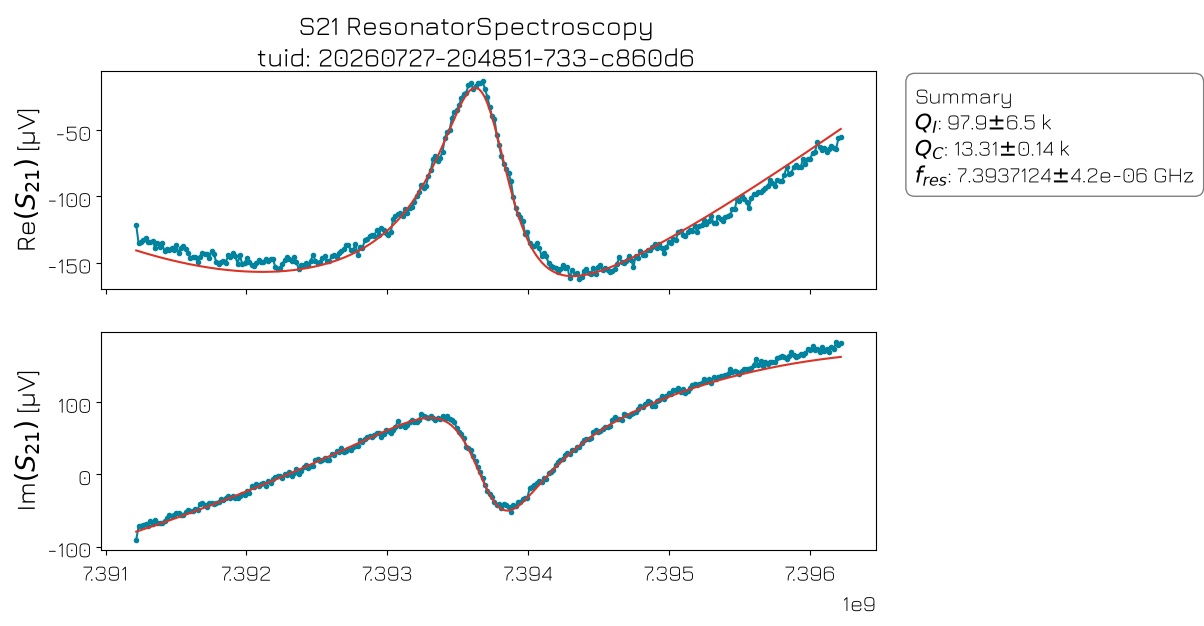

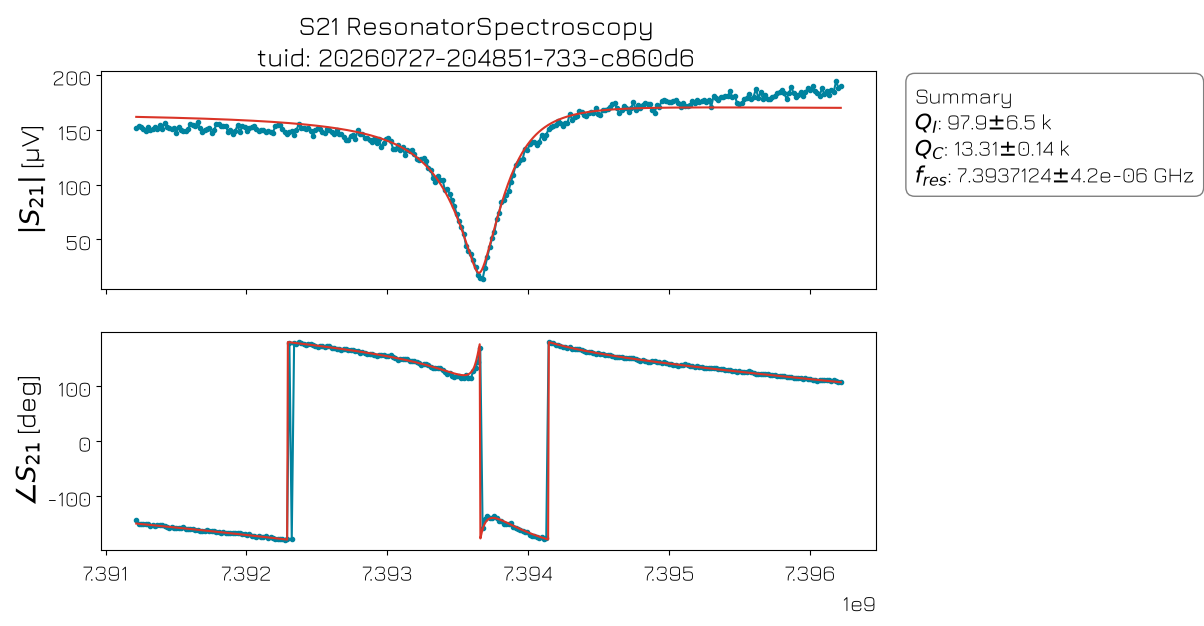

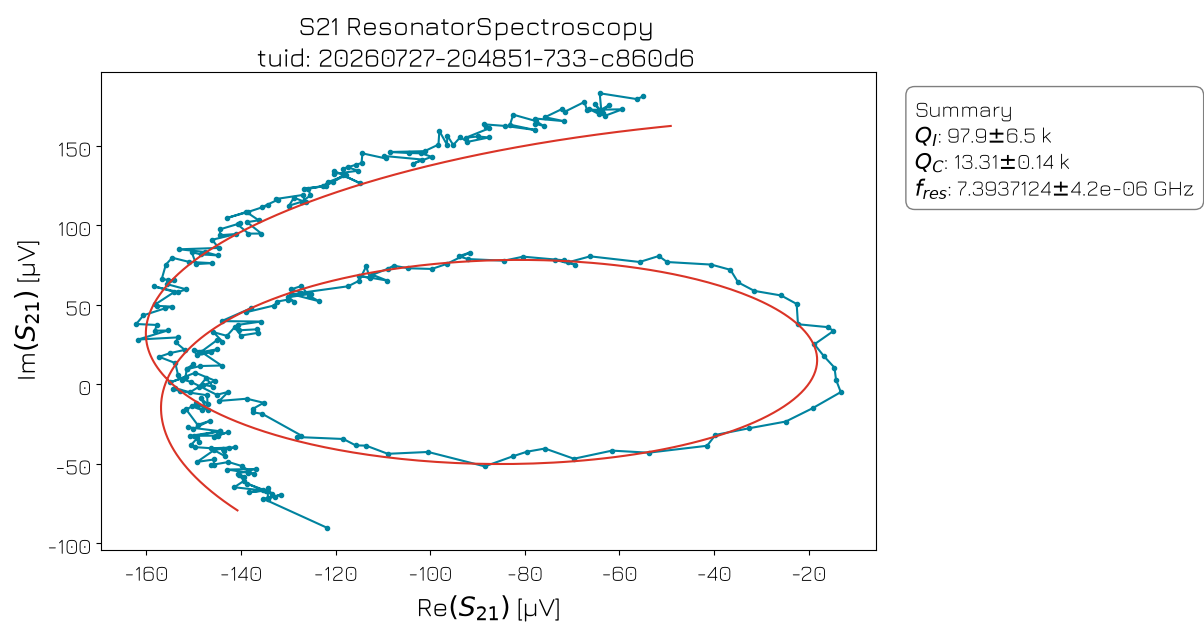

In [ ]:
resspec_analysis = ResonatorSpectroscopyAnalysis(rs_data).run()
resspec_analysis.display_figs_mpl()

## Post-run

In [ ]:
# Update device config
qubit.clock_freqs.readout = resspec_analysis.quantities_of_interest["fr"].nominal_value

#### Update the device configuration file
After measurement, we may store the measured device properties inside a new file to use in future experiments.
The time-unique identifier ensures that it is easy to find back previously found measurement results.

In [ ]:
hw_agent.quantum_device.to_json_file("./dependencies/configs", add_timestamp=True)

'./dependencies/configs/two_flux_tunable_transmons_2026-07-27_20-48-54_UTC.json'